# Extended Hertz reference notebook for two overlapping cells

This notebook is a reference specification for a benchmark with two identical cells interacting through the extended Hertz model.

It is organized so developers can agree on the benchmark parameters and on the expected outputs:

- Analytical reference for the force law and equilibrium overlap.
- Numerical reference for the time evolution of the overlap.

The notebook does not analyze any simulator output. It only defines the target behavior that an implementation should reproduce.

## Model definition

For two identical cells with radius $R$, let $\delta(t)$ denote the overlap. The extended Hertz contact force is

$$
F(\delta) = \begin{cases}
\frac{4}{3} E^* \sqrt{R_{\mathrm{eff}}}\,\delta^{3/2} - \pi \gamma R_{\mathrm{eff}}, & \delta > 0, \\
0, & \delta \le 0,
\end{cases}
$$

with

$$
R_{\mathrm{eff}} = \left(\frac{1}{R_1}+\frac{1}{R_2}\right)^{-1}, \qquad
E^* = \left(\frac{1-\nu_1^2}{E_1}+\frac{1-\nu_2^2}{E_2}\right)^{-1}.
$$

The benchmark uses two kinds of reference outputs:

- Analytical outputs: force as a function of overlap, effective parameters, and equilibrium overlap.
- Numerical outputs: overlap trajectory from the overdamped ODE

$$
\frac{d\delta}{dt} = -\frac{2}{\zeta} F(\delta),
$$

where $\zeta$ is the translational drag coefficient.

## Adhesion parameter

The adhesion parameter is defined from the adhesion molecule surface density $\sigma_m$ and the single-bond work $W_s$ as

$$
\gamma = \sigma_m W_s,
$$

with

$$
W_s = 20 \, k_B T
$$

for this benchmark.

## Benchmark parameters

The agreed benchmark setup is:

- Two identical cells.
- Radius $R = 5\,\mu\mathrm{m}$ for each cell.
- Initial overlap $\delta_0 = 1\,\mu\mathrm{m}$, which is 10% of the diameter.
- Young's modulus $E = 450\,\mathrm{Pa}$ for each cell.
- Poisson ratio $\nu = 0.4$ for each cell.
- Adhesion density $\sigma_m = 10^{15}\,\mathrm{m}^{-2}$.
- Single-bond work $W_s = 20 k_B T$ at $T = 310\,\mathrm{K}$.
- Drag coefficient $\zeta = 0.1\,\mathrm{N\,s/m}$ for the overdamped time evolution.

In [19]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import solve_ivp

k_B = 1.380649e-23  # J/K
T_K = 310.0

radius_um = 5.0
initial_overlap_um = 1.0
young_modulus_Pa = 450.0
poisson_ratio = 0.4

adhesion_density_per_m2 = 1.0e15
bond_work_multiple_of_kBT = 20.0
drag_Ns_per_m = 0.1
time_window_s = 120.0

radius_m = radius_um * 1e-6
gamma_J_per_m2 = adhesion_density_per_m2 * bond_work_multiple_of_kBT * k_B * T_K
R_eff_m = 1.0 / (1.0 / radius_m + 1.0 / radius_m)
E_star_Pa = 1.0 / (2.0 * (1.0 - poisson_ratio ** 2) / young_modulus_Pa)

A_SI = (4.0 / 3.0) * E_star_Pa * math.sqrt(R_eff_m)
B_SI = math.pi * gamma_J_per_m2 * R_eff_m
equilibrium_overlap_m = (B_SI / A_SI) ** (2.0 / 3.0)
equilibrium_overlap_um = equilibrium_overlap_m * 1e6

def extended_hertz_force_N(overlap_um):
    overlap_um = np.asarray(overlap_um, dtype=float)
    overlap_m = np.maximum(overlap_um, 0.0) * 1e-6
    force_N = A_SI * overlap_m ** 1.5 - B_SI
    return np.where(overlap_um > 0.0, force_N, 0.0)

def extended_hertz_force_nN(overlap_um):
    return 1e9 * extended_hertz_force_N(overlap_um)

parameter_summary = pd.DataFrame(
    {
        'parameter': [
            'radius',
            'initial_overlap',
            'young_modulus',
            'poisson_ratio',
            'adhesion_density',
            'bond_work',
            'gamma',
            'effective_radius',
            'effective_modulus',
            'drag',
            'equilibrium_overlap',
        ],
        'value': [
            radius_um,
            initial_overlap_um,
            young_modulus_Pa,
            poisson_ratio,
            adhesion_density_per_m2,
            bond_work_multiple_of_kBT * k_B * T_K,
            gamma_J_per_m2,
            R_eff_m * 1e6,
            E_star_Pa,
            drag_Ns_per_m,
            equilibrium_overlap_um,
        ],
        'units': [
            'um',
            'um',
            'Pa',
            'dimensionless',
            '1/m^2',
            'J',
            'J/m^2',
            'um',
            'Pa',
            'N*s/m',
            'um',
        ],
    }
)

parameter_summary

,parameter,value,units
0,radius,5.000000e+00,um
1,initial_overlap,1.000000e+00,um
2,young_modulus,4.500000e+02,Pa
3,poisson_ratio,4.000000e-01,dimensionless
4,adhesion_density,1.000000e+15,1/m^2
5,bond_work,8.560024e-20,J
6,gamma,8.560024e-05,J/m^2
7,effective_radius,2.500000e+00,um
8,effective_modulus,2.678571e+02,Pa
9,drag,1.000000e-01,N*s/m


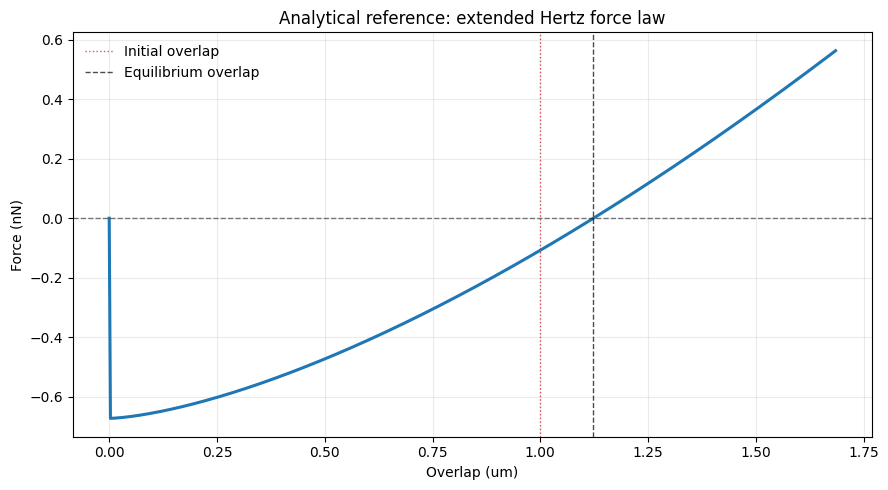

,quantity,value,units
0,force_at_initial_overlap,-1.076103e-01,nN
1,force_at_equilibrium_overlap,8.271806e-16,nN
2,equilibrium_overlap,1.123316e+00,um


In [20]:
analytical_overlap_grid_um = np.linspace(
    0.0,
    max(1.5 * max(initial_overlap_um, equilibrium_overlap_um), 1e-6),
    600,
 )
analytical_force_grid_nN = extended_hertz_force_nN(analytical_overlap_grid_um)

analytical_summary = pd.DataFrame(
    {
        'quantity': [
            'force_at_initial_overlap',
            'force_at_equilibrium_overlap',
            'equilibrium_overlap',
        ],
        'value': [
            float(extended_hertz_force_nN(initial_overlap_um)),
            float(extended_hertz_force_nN(equilibrium_overlap_um)),
            equilibrium_overlap_um,
        ],
        'units': ['nN', 'nN', 'um'],
    }
)

fig_force, ax_force = plt.subplots(figsize=(9, 5))
ax_force.plot(analytical_overlap_grid_um, analytical_force_grid_nN, color='#1f77b4', linewidth=2.2)
ax_force.axhline(0.0, color='black', linewidth=1.0, alpha=0.5, linestyle='--')
ax_force.axvline(initial_overlap_um, color='#d62728', linewidth=1.0, alpha=0.8, linestyle=':', label='Initial overlap')
ax_force.axvline(equilibrium_overlap_um, color='black', linewidth=1.0, alpha=0.7, linestyle='--', label='Equilibrium overlap')
ax_force.set_xlabel('Overlap (um)')
ax_force.set_ylabel('Force (nN)')
ax_force.set_title('Analytical reference: extended Hertz force law')
ax_force.grid(True, alpha=0.25)
ax_force.legend(frameon=False)

plt.tight_layout()
plt.show()

analytical_summary

In [21]:
reference_overlaps_um = np.array([0.25, 0.50, 0.75, 1.00, equilibrium_overlap_um, 1.25])
reference_overlaps_um = np.unique(np.round(reference_overlaps_um, 6))

force_reference_table = pd.DataFrame(
    {
        'overlap_um': reference_overlaps_um,
        'force_nN': extended_hertz_force_nN(reference_overlaps_um),
    }
)

force_reference_table

,overlap_um,force_nN
0,0.250000,-6.017161e-01
1,0.500000,-4.726538e-01
2,0.750000,-3.055242e-01
3,1.000000,-1.076103e-01
4,1.123316,5.678397e-08
5,1.250000,1.168790e-01


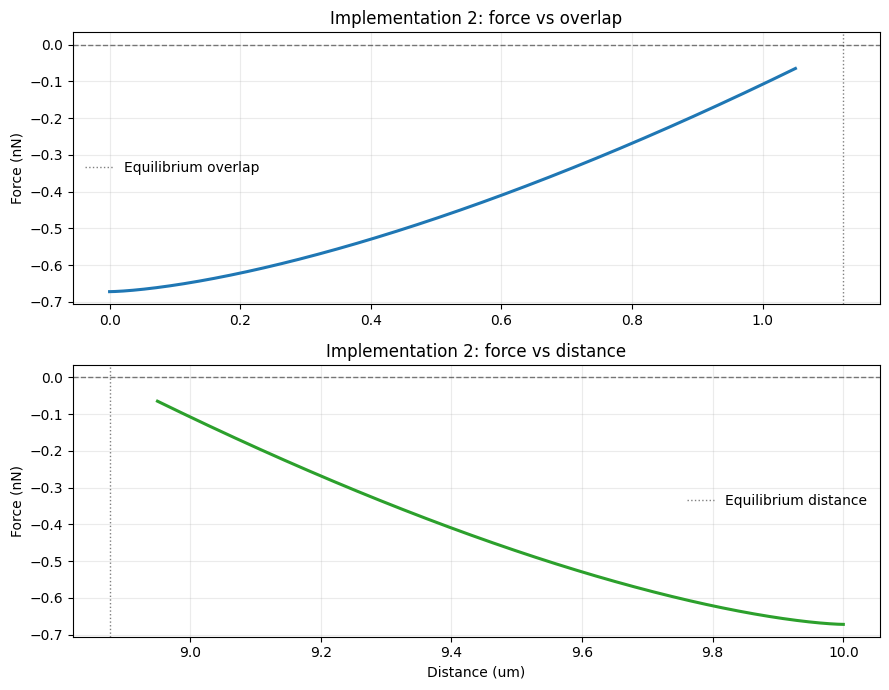

,parameter,value,units
0,gamma,0.000086,J/m^2
1,delta_eq,1.123316,um
2,d_eq,8.876684,um


In [ ]:
## Numerical reference for the time behavior

The expected time behavior is defined by the overdamped overlap ODE

$$
\frac{d\delta}{dt} = -\frac{2}{\zeta} F(\delta).
$$

This section computes the benchmark overlap trajectory numerically from the same parameter set used in the analytical section.

The outputs below are the time-dependent reference quantities that simulator developers should compare against:

- overlap as a function of time,
- force as a function of time along that trajectory,
- sampled benchmark values at selected times.

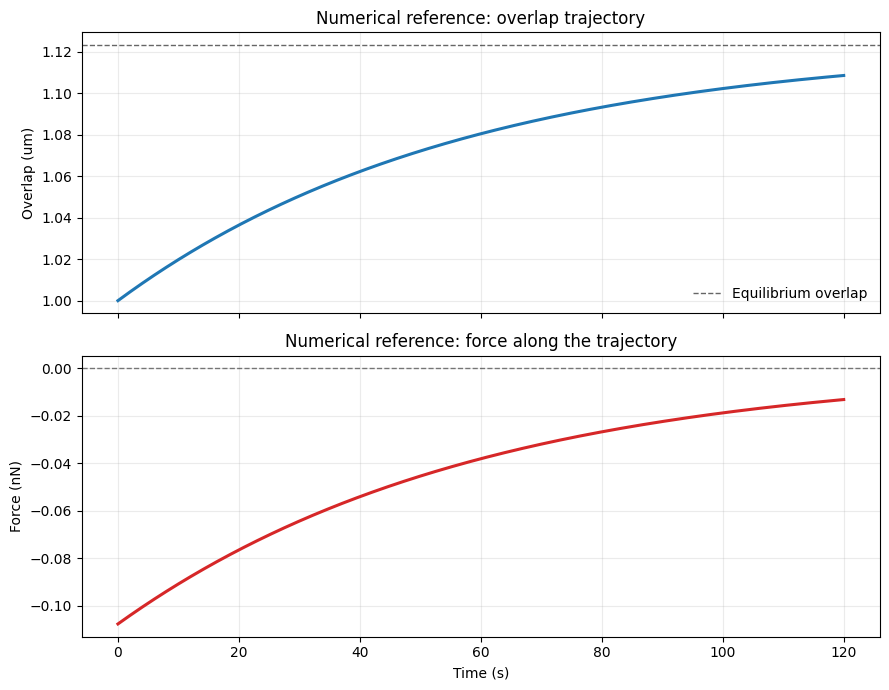

(              quantity       value units
 0      initial_overlap    1.000000    um
 1  equilibrium_overlap    1.123316    um
 2        final_overlap    1.108658    um
 3        initial_force   -0.107610    nN
 4          final_force   -0.013116    nN
 5     time_window_used  120.000000     s,
    time_s  overlap_um  force_nN
 0     0.0    1.000000 -0.107610
 1    10.0    1.019792 -0.090763
 2    20.0    1.036473 -0.076436
 3    40.0    1.062313 -0.054015
 4    60.0    1.080541 -0.038033
 5    90.0    1.098255 -0.022372
 6   120.0    1.108658 -0.013116)

In [22]:
def overlap_rhs(_time_s, state):
    overlap_um = max(float(state[0]), 0.0)
    relative_speed_um_per_s = 2.0 * float(extended_hertz_force_N(overlap_um)) / drag_Ns_per_m * 1e6
    return [-relative_speed_um_per_s]

def reach_equilibrium(_time_s, state):
    return state[0] - equilibrium_overlap_um

def reach_detachment(_time_s, state):
    return state[0]

reach_equilibrium.terminal = True
reach_equilibrium.direction = -1 if initial_overlap_um > equilibrium_overlap_um else 1
reach_detachment.terminal = True
reach_detachment.direction = -1

solution = solve_ivp(
    overlap_rhs,
    t_span=(0.0, time_window_s),
    y0=[initial_overlap_um],
    events=[reach_equilibrium, reach_detachment],
    dense_output=True,
    max_step=0.1,
    rtol=1e-8,
    atol=1e-10,
 )

if solution.t_events[0].size > 0:
    t_end_s = float(solution.t_events[0][0])
elif solution.t_events[1].size > 0:
    t_end_s = float(solution.t_events[1][0])
else:
    t_end_s = float(solution.t[-1])

time_s = np.linspace(0.0, t_end_s, 600)
overlap_um = solution.sol(time_s)[0]
overlap_um = np.maximum(overlap_um, 0.0)
if initial_overlap_um > equilibrium_overlap_um:
    overlap_um = np.maximum(overlap_um, equilibrium_overlap_um)
else:
    overlap_um = np.minimum(overlap_um, equilibrium_overlap_um)

force_nN = extended_hertz_force_nN(overlap_um)

trajectory_summary = pd.DataFrame(
    {
        'quantity': [
            'initial_overlap',
            'equilibrium_overlap',
            'final_overlap',
            'initial_force',
            'final_force',
            'time_window_used',
        ],
        'value': [
            initial_overlap_um,
            equilibrium_overlap_um,
            float(overlap_um[-1]),
            float(force_nN[0]),
            float(force_nN[-1]),
            t_end_s,
        ],
        'units': ['um', 'um', 'um', 'nN', 'nN', 's'],
    }
)

reference_times_s = np.array([0.0, 10.0, 20.0, 40.0, 60.0, 90.0, min(120.0, t_end_s)])
reference_times_s = np.unique(np.round(reference_times_s[reference_times_s <= t_end_s], 6))
trajectory_reference_table = pd.DataFrame(
    {
        'time_s': reference_times_s,
        'overlap_um': np.interp(reference_times_s, time_s, overlap_um),
        'force_nN': np.interp(reference_times_s, time_s, force_nN),
    }
)

fig_traj, axes_traj = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes_traj[0].plot(time_s, overlap_um, color='#1f77b4', linewidth=2.2)
axes_traj[0].axhline(equilibrium_overlap_um, color='black', linewidth=1.0, alpha=0.6, linestyle='--', label='Equilibrium overlap')
axes_traj[0].set_ylabel('Overlap (um)')
axes_traj[0].set_title('Numerical reference: overlap trajectory')
axes_traj[0].grid(True, alpha=0.25)
axes_traj[0].legend(frameon=False)

axes_traj[1].plot(time_s, force_nN, color='#d62728', linewidth=2.2)
axes_traj[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.5, linestyle='--')
axes_traj[1].set_xlabel('Time (s)')
axes_traj[1].set_ylabel('Force (nN)')
axes_traj[1].set_title('Numerical reference: force along the trajectory')
axes_traj[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

trajectory_summary, trajectory_reference_table